In [1]:
import numpy as np
import matplotlib.pyplot as plt
from zsindy.ml_module import ZSindy
from pathlib import Path
import pandas as pd
from matplotlib.lines import Line2D

try:
    from matplotlib import font_manager
    font_manager.fontManager.addfont('/usr/share/fonts/truetype/msttcorefonts/Arial.ttf')
    prop = font_manager.FontProperties(fname='/usr/share/fonts/truetype/msttcorefonts/Arial.ttf')
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = prop.get_name()
except Exception as e:
    print('Could not load Arial font')
    print(e)

# ZSindy parameters
poly_degree = 3
lmbda = 1e3 # Regularization parameter
zsindy_num_terms = 5 # Maximum number of terms to include in the model



/home/oriolca/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


# Strogatz dataset - low noise regime

Model: ../strogatz/datasets/bact_res_SNR_50_0.csv
( x )' =  + 19.6292 1 + -0.9672 x + -0.4914 y + 0.0412 x*y + -0.0012 x**2*y
( y )' =  + 9.6837 1 + -0.5095 y + 0.0464 x*y + -0.0013 x**2*y + -0.0000 x*y**2


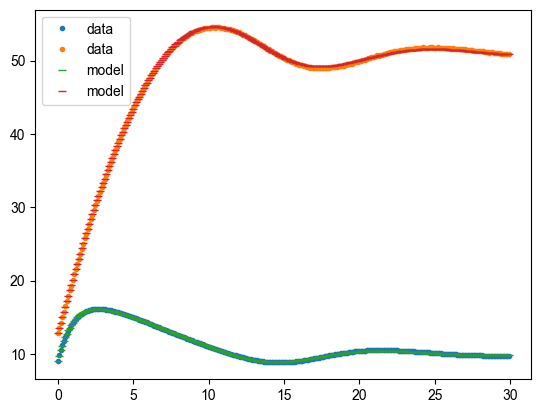

Model: ../strogatz/datasets/bar_mag_SNR_50_0.csv
( x )' =  + 0.1015 y**2 + 0.0285 x**3 + -0.0445 x**2*y
( y )' =  + -3.9730 x + 5.7186 y + -0.5814 y**2 + 0.0480 x**2*y


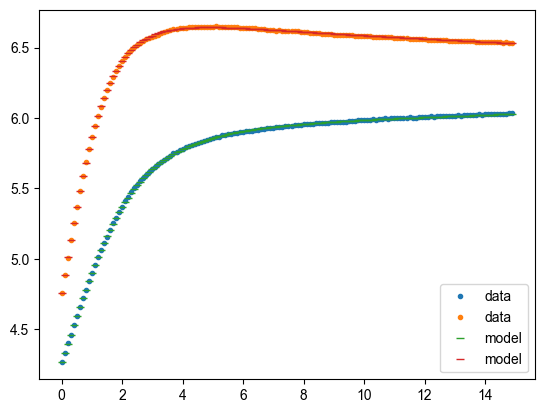

Model: ../strogatz/datasets/glider_SNR_50_0.csv
( x )' =  + -1.9682 1 + 0.0350 x*y + 0.0037 y**2 + -0.0010 x*y**2 + -0.0001 y**3
( y )' =  + 6.7164 1 + -0.3112 x*y + 0.0438 x**2*y + 0.0066 x*y**2 + -0.0001 y**3


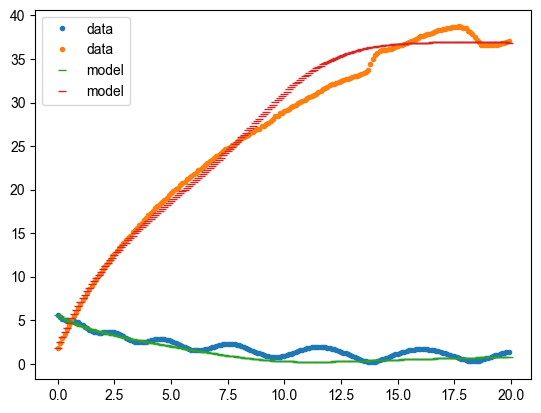

Model: ../strogatz/datasets/lotka_volterra_SNR_50_0.csv
( x )' =  + -26.7625 x + -12.9022 x**2 + 36.2943 x*y + 32.9046 x**3 + -11.7313 x*y**2
( y )' =  + -20.8076 x + -22.2968 x**2 + 30.6726 x*y + 33.0805 x**3 + -9.7050 x*y**2


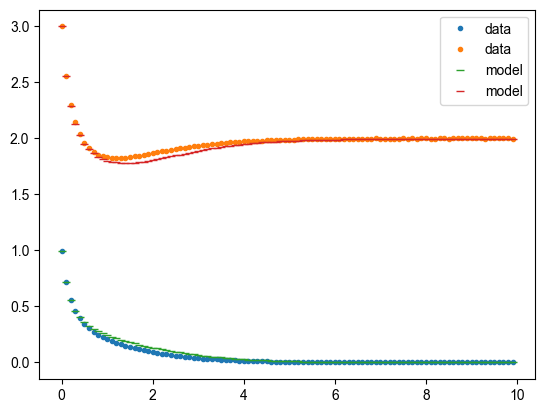

Model: ../strogatz/datasets/pred_prey_SNR_50_0.csv
( x )' =  + 2.7278 x + -0.4954 x*y + -0.0043 y**2 + -0.1913 x**3 + 0.0878 x**2*y
( y )' =  + -0.5563 x**2 + 0.6342 x*y + -0.0691 y**2 + 0.2339 x**3 + -0.1489 x**2*y


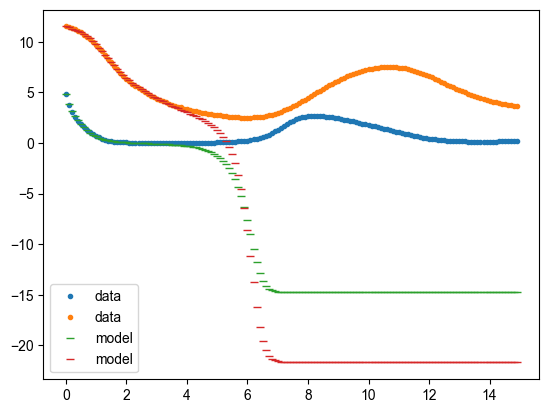

Model: ../strogatz/datasets/sh_flow_SNR_50_0.csv
( x )' =  + 6.8406 y + 2.6051 x**2 + 7.1685 y**2 + 1.8719 x**2*y + 1.6195 y**3
( y )' =  + 1.6155 x + 1.9602 x*y + 0.6224 x*y**2
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1206826928023D+02   r2 =  0.8441222963845D-15
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1206826928023D+02   r2 =  0.8441222963845D-15
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1206826928023D+02   r2 =  0.8441222963845D-15
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on

/home/oriolca/.local/lib/python3.10/site-packages/zsindy/ml_module.py:156: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  return odeint(self.model_integrator.poly_system, x0, t, args=(coefs,))


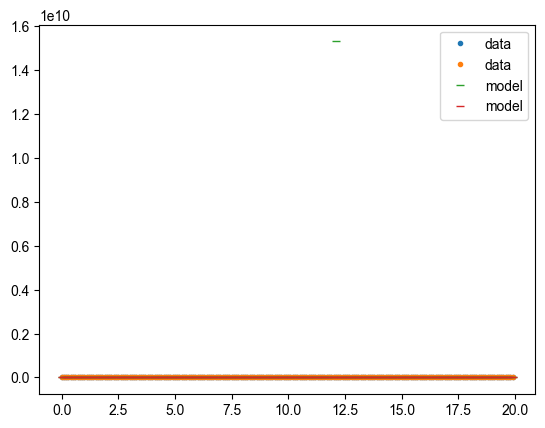

Model: ../strogatz/datasets/vd_pol_SNR_50_0.csv
( x )' =  + 2.9427 x + 10.0747 y + -2.9668 x**3 + -1.1474 x**2*y + 5.5109 x*y**2
( y )' =  + -0.0998 x


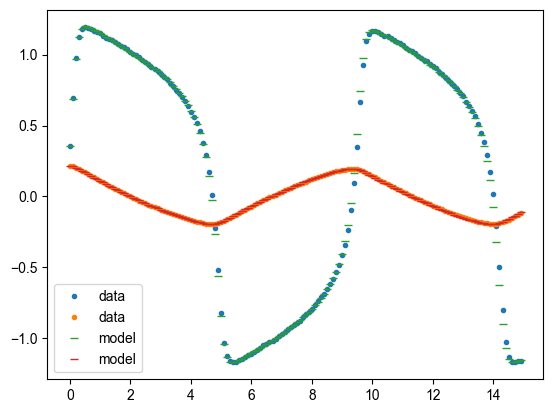

In [2]:
# Select the first dataset of the low noise regime for each system.
folder = Path("../strogatz/datasets")

files = [
    f for f in folder.iterdir()
    if f.is_file() and "50_0" in f.name
]

for f in files:
    print('Model:',f)
    data = pd.read_csv(f)
    X = data[['x','y']].to_numpy()
    time = data.t.to_numpy()
    ## Z-Sindy
    zmodel = ZSindy(lmbda=lmbda, 
            max_num_terms=zsindy_num_terms, 
            poly_degree=poly_degree,
            variable_names=['x','y'])
    
    zmodel.fit(X, time)
    
    zmodel.print()
    z_x_pred = zmodel.simulate(X[0], time)
    plt.plot(time, X, '.',label = 'data')
    plt.plot(time, z_x_pred, '_', label = 'model')
    plt.legend()
    plt.show()
    

# Strogatz dataset - high noise regime

( x )' =  + 5.8981 x + -0.4708 y + -0.6238 x**2 + 0.0182 x**3 + 0.0004 x*y**2
( y )' =  + 6.2212 x + -0.5958 y + -0.6581 x**2 + 0.0210 x**3 + 0.0005 x*y**2


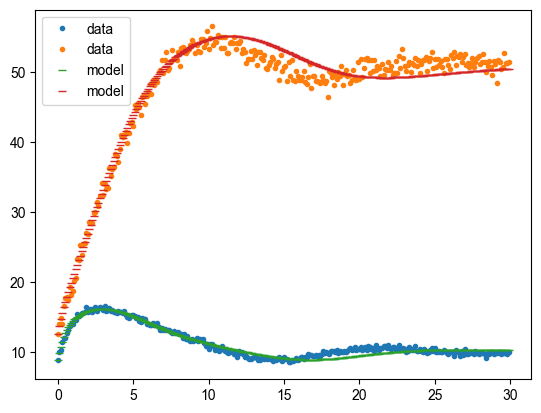

( x )' =  + -137.8671 1 + 70.4822 y + -11.8429 y**2 + -0.0110 x*y**2 + 0.6659 y**3
( y )' =  + -144.9383 1 + 74.8917 y + -12.6339 y**2 + -0.0077 x*y**2 + 0.7060 y**3


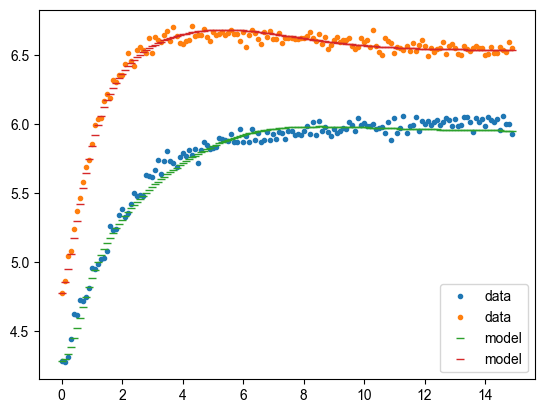

( x )' =  + -1.4625 1 + 0.0461 y + 0.2717 x**2 + -0.0103 x*y + -0.0562 x**3
( y )' =  + 3.6542 x + 0.1347 y + -2.1758 x**2 + -0.0043 y**2 + 0.3555 x**3


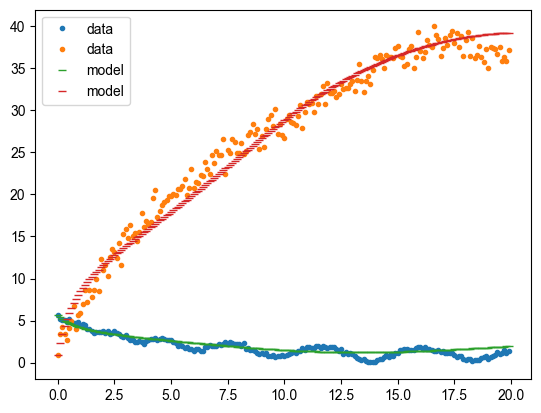

( x )' =  + 57.8556 x + 58.5556 x**2 + -70.1394 x*y + -32.0522 x**2*y + 20.7738 x*y**2
( y )' =  + 7.1186 x + -2.7795 x*y + 21.9976 x**3 + -8.9426 x**2*y + 0.0025 y**3


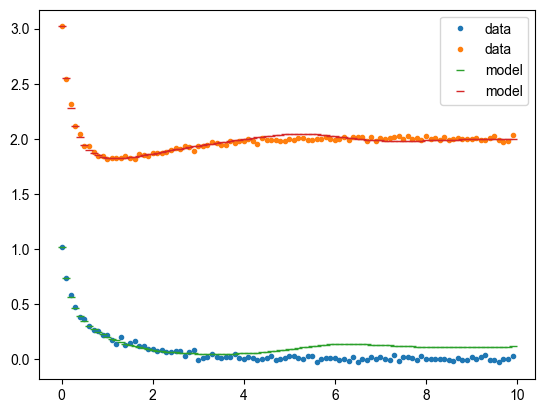

( x )' =  + 2.7358 x + -0.4782 x*y + -0.0055 y**2 + -0.2011 x**3 + 0.0864 x**2*y
( y )' =  + 1.5518 x + -0.2446 y + -0.4600 x**2 + 0.1895 x*y + -0.0035 y**3


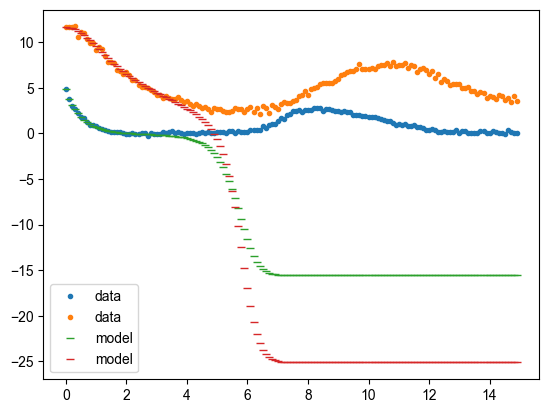

( x )' =  + -2.5740 1 + -1.5764 y + 1.3081 x**2 + -0.0117 x**3 + 0.7869 x**2*y
( y )' =  + 1.4792 x + 0.0609 x**2 + 1.8199 x*y + 0.0358 x**2*y + 0.5880 x*y**2


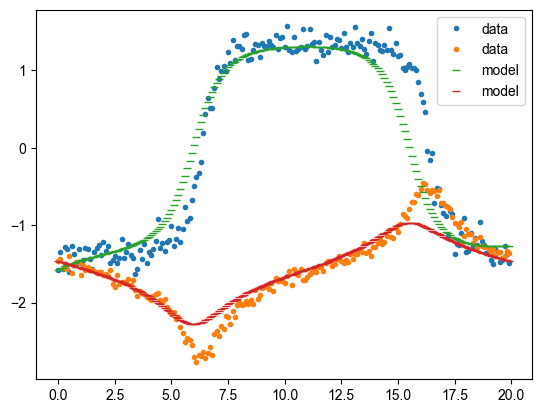

( x )' =  + 0.1972 x + 9.6007 y + -0.3674 x**3 + -7.7602 x**2*y + 37.0915 x*y**2
( y )' =  + -0.2148 x + -0.2507 y**2 + 0.1071 x**3 + -0.3367 x**2*y + 1.5269 x*y**2


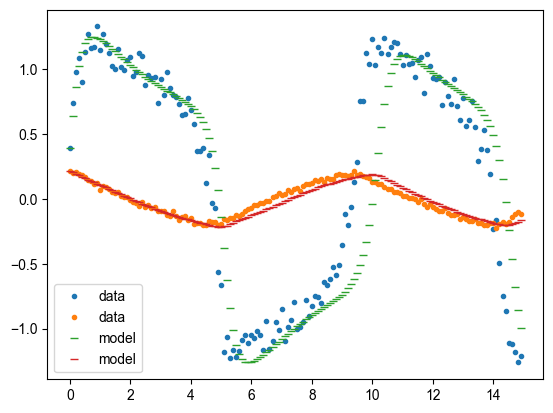

In [3]:
# Select the first dataset of the low noise regime for each system.
folder = Path("../strogatz/datasets")

files = [
    f for f in folder.iterdir()
    if f.is_file() and "20_0" in f.name
]

for f in files:
    data = pd.read_csv(f)
    X = data[['x','y']].to_numpy()
    time = data.t.to_numpy()
    ## Z-Sindy
    zmodel = ZSindy(lmbda=lmbda, 
            max_num_terms=zsindy_num_terms, 
            poly_degree=poly_degree,
            variable_names=['x','y'])
    
    zmodel.fit(X, time)
    
    zmodel.print()
    z_x_pred = zmodel.simulate(X[0], time)
    plt.plot(time, X, '.',label = 'data')
    plt.plot(time, z_x_pred, '_', label = 'model')
    plt.legend()
    plt.show()

<class 'zsindy.ml_module.ZSindy'>
['Fs', 'Theta', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_compute_partition', '_dict_to_lists', '_free_energy', '_free_energy_coefs', '_get_idx_combinations', '_normalized_fe', '_optimize_all_dimensions', '_optimize_per_num_terms_per_dim', '_optimize_upto_num_terms_per_dim', '_sparse_penalty_fe', '_zprobability', 'coefficients', 'coefficients_variance', 'differentiate_state', 'feat_comb_list', 'fit', 'gamma_opt', 'get_feat_names', 'get_feature_combinations', 'get_free_energies', 'get_gammas', 'get_library_matrix', 'get_probabilities', 'lmbda', 'max_num_terms', 'model_integrator', 'normalize_lambda', 'num_dims', 'poly_degree', 'predict', 'print', 'prob_op

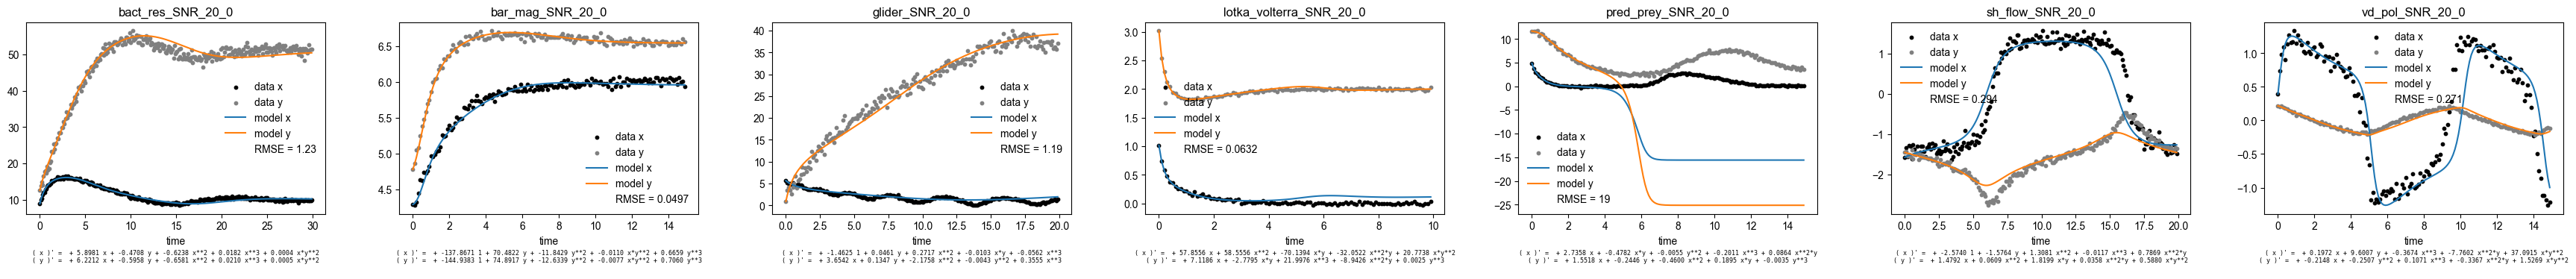

In [4]:
fig, axes = plt.subplots(1, len(files), figsize=(5*len(files), 4))

if len(files) == 1:
    axes = [axes]

for ax, f in zip(axes, files):

    data = pd.read_csv(f)
    X = data[['x','y']].to_numpy()
    time = data.t.to_numpy()

    zmodel = ZSindy(
        lmbda=lmbda,
        max_num_terms=zsindy_num_terms,
        poly_degree=poly_degree,
        variable_names=['x','y']
    )

    zmodel.fit(X, time)
    pred = zmodel.simulate(X[0], time)

    rmse = np.sqrt(np.mean((pred - X)**2))

    ax.scatter(time, X[:,0], s=10, c='k', label='data x')
    ax.scatter(time, X[:,1], s=10, c='grey', label='data y')

    ax.plot(time, pred[:,0], c='tab:blue', label='model x')
    ax.plot(time, pred[:,1], c='tab:orange', label='model y')

    rmse_entry = Line2D([], [], linestyle='None',
                        label=f'RMSE = {rmse:.3g}')

    handles, labels = ax.get_legend_handles_labels()
    handles.append(rmse_entry)

    print(type(zmodel))
    print(dir(zmodel))
    print(zmodel.print())

    import inspect

    print(inspect.getsource(zmodel.print))

    from io import StringIO
    from contextlib import redirect_stdout
    
    buf = StringIO()
    with redirect_stdout(buf):
        zmodel.print()
    
    equations = buf.getvalue()

    ax.text(
        0.5, -0.3,
        equations,
        transform=ax.transAxes,
        ha='center',
        va='bottom',
        fontsize=6,
        family='monospace'
    )

    ax.legend(handles=handles, frameon=False)
    ax.set_title(f.stem)
    ax.set_xlabel("time")
plt.tight_layout()
plt.savefig('zsindy_models.pdf',dpi=300)

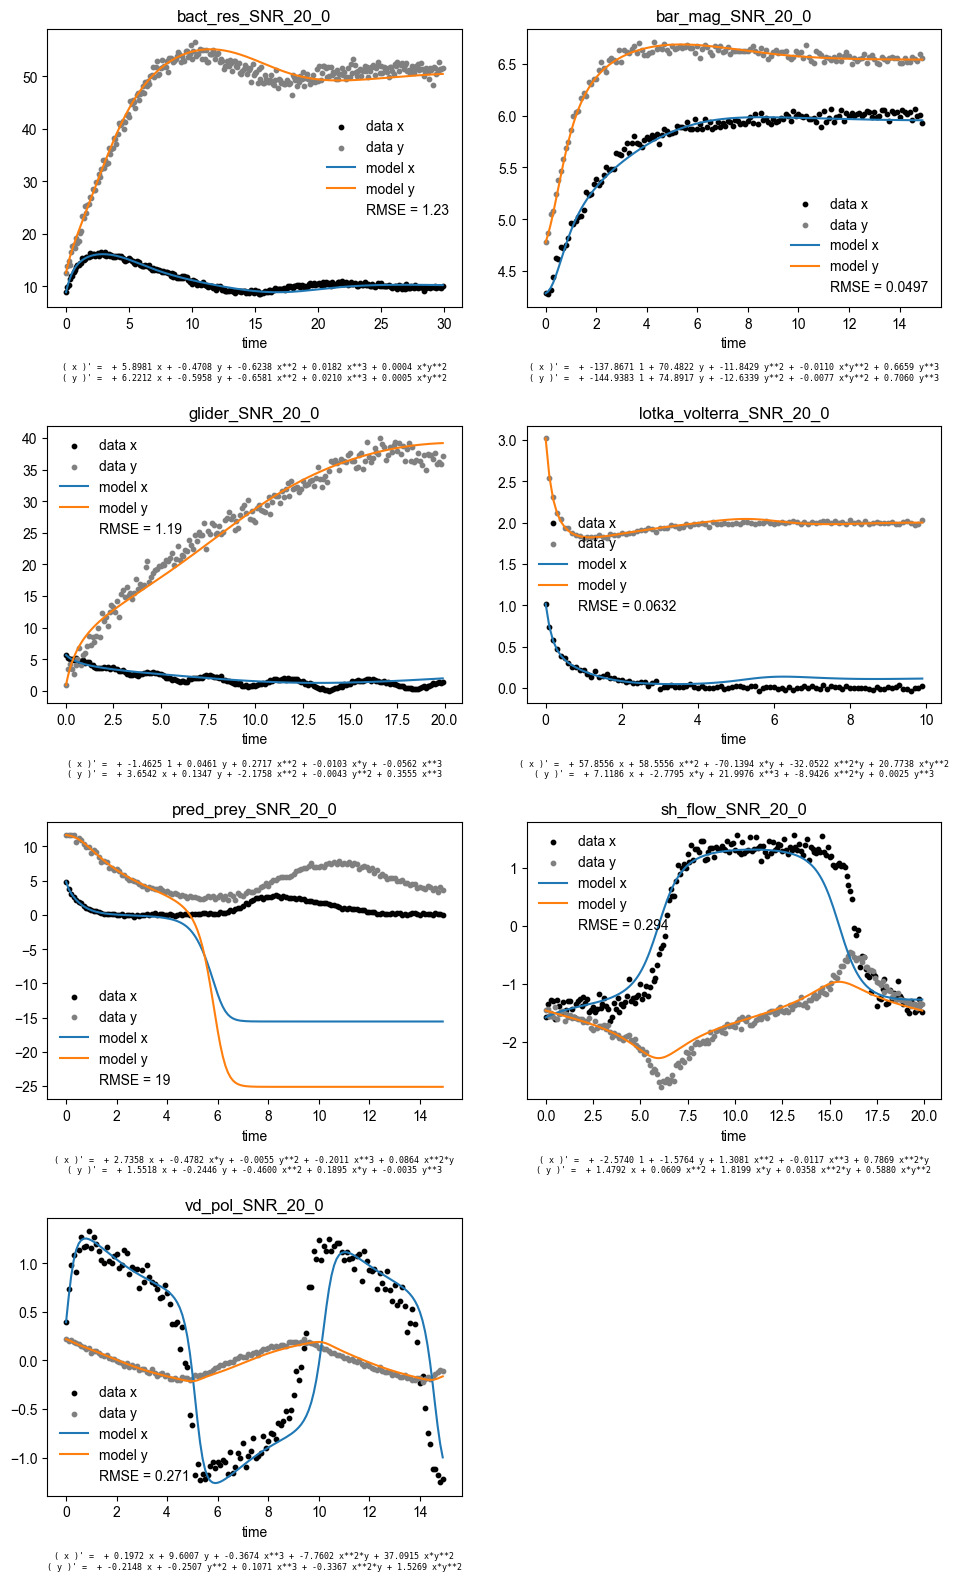

In [7]:
import math

n_files = len(files)
ncols = 2
nrows = math.ceil(n_files / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(10, 4 * nrows),
    squeeze=False
)

# Flatten so we can iterate over axes easily
axes = axes.flatten()

for ax, f in zip(axes, files):

    data = pd.read_csv(f)
    X = data[['x','y']].to_numpy()
    time = data.t.to_numpy()

    zmodel = ZSindy(
        lmbda=lmbda,
        max_num_terms=zsindy_num_terms,
        poly_degree=poly_degree,
        variable_names=['x','y']
    )

    zmodel.fit(X, time)
    pred = zmodel.simulate(X[0], time)

    rmse = np.sqrt(np.mean((pred - X)**2))

    ax.scatter(time, X[:,0], s=10, c='k', label='data x')
    ax.scatter(time, X[:,1], s=10, c='grey', label='data y')

    ax.plot(time, pred[:,0], c='tab:blue', label='model x')
    ax.plot(time, pred[:,1], c='tab:orange', label='model y')

    rmse_entry = Line2D([], [], linestyle='None',
                        label=f'RMSE = {rmse:.3g}')

    handles, labels = ax.get_legend_handles_labels()
    handles.append(rmse_entry)

    from io import StringIO
    from contextlib import redirect_stdout

    buf = StringIO()
    with redirect_stdout(buf):
        zmodel.print()

    equations = buf.getvalue()

    ax.text(
        0.5, -0.20,
        equations,
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=6,
        family='monospace'
    )

    ax.legend(handles=handles, frameon=False)
    ax.set_title(f.stem)
    ax.set_xlabel("time")

# Remove any unused axes (e.g. if len(files) is odd)
for ax in axes[n_files:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.savefig("zsindy_models1.pdf", dpi=300, bbox_inches="tight")